## Assignment 2 - Formula 1 Dataset Analysis

Which three constructors earned the most points between 1981 and 2020? How many total points did each of them earn? How do the total points for each constructor compare with the average across constructors?

In [ ]:


import pandas as pd

results = pd.read_csv("C:/Users/adamk/OneDrive/Documents/GitHub/datasci530fall2026/Lecture 03/data_raw/constructor_results.csv")
races = pd.read_csv("C:/Users/adamk/OneDrive/Documents/GitHub/datasci530fall2026/Lecture 03/data_raw/races.csv")

merged = results.merge(
    races[['raceId', 'year', 'name', 'date']],
    on='raceId',
    how='left',
    suffixes=('_result', '_race')
)


merged.sort_values(by='points', ascending=False, inplace=True)
merged = merged[merged['year'].between(1981, 2020)]
print(merged.head(100))

# The three constructors that earned the most points between 1981 and 2020 are:
# - Williams at the 2014 Abu Dhabi Grand Prix, 66.0 points
# - Mercedes at the 2014 Abu Dhabi Grand Prix, 50.0 points
# - Mercedes at the 2019 Russian Grand Prix, 44.0 points

mean = average_points = merged['points'].mean()
print(mean)

# The average number of total points across all these constructors is approximately
# 4.16 points, which is much smaller than a majority of these constructors. However,
# a lot of the constructors that did have less points than the averagehad a
# total of 0 points, which is why the average is so low.


       constructorResultsId  raceId  constructorId  points status  year  \
10507                 15006     918              3    66.0     \N  2014   
10506                 15005     918            131    50.0     \N  2014   
11500                 16000    1025            131    44.0     \N  2019   
11670                 16170    1042            131    44.0     \N  2020   
11640                 16140    1039            131    44.0     \N  2020   
...                     ...     ...            ...     ...    ...   ...   
10049                 14548     876              9    40.0     \N  2012   
10637                 15135     939              6    40.0     \N  2015   
11122                 15620     987              6    40.0     \N  2017   
9834                  14332     858              1    40.0     \N  2011   
9714                  14212     848              9    40.0     \N  2011   

                        name        date  
10507   Abu Dhabi Grand Prix  2014-11-23  
10506   Abu D

Which three constructors earned the most points between 2001 and 2020? How many total points did each of them earn? How do the total points for each constructor compare with the average across constructors?

In [ ]:

merged.sort_values(by='points', ascending=False, inplace=True)
merged = merged[merged['year'].between(2001, 2020)]
print(merged.head(100))

# The three constructors that earned the most points between 2001 and 2020 are:
# - Williams at the 2014 Abu Dhabi Grand Prix, 66.0 points
# - Mercedes at the 2014 Abu Dhabi Grand Prix, 50.0 points
# - Mercedes at the 2020 Emilia Romagna Grand Prix, 44.0 points

mean = average_points = merged['points'].mean()
print(mean)

# The average number of total points across all these constructors is approximately
# 6.95 points, which is noticeably higher than the average from the previous time period.


       constructorResultsId  raceId  constructorId  points status  year  \
10507                 15006     918              3    66.0     \N  2014   
10506                 15005     918            131    50.0     \N  2014   
11680                 16180    1043            131    44.0     \N  2020   
11390                 15890    1014            131    44.0     \N  2019   
11640                 16140    1039            131    44.0     \N  2020   
...                     ...     ...            ...     ...    ...   ...   
11272                 15770    1002            131    40.0     \N  2018   
11142                 15640     989              6    40.0     \N  2018   
10566                 15064     931            131    40.0     \N  2015   
11520                 16020    1027            131    40.0     \N  2019   
10141                 14640     884              6    40.0     \N  2013   

                            name        date  
10507       Abu Dhabi Grand Prix  2014-11-23  
10506

How did the rankings change across the two time periods?

In [ ]:
# The average rankings in terms of points increased from a to b
# because the sample size of constructors decreased, and the number
# of constructors that earned 0 points decreased as well. This is
# likely due to the fact that the constructors that did not earn
# any points were not as competitive as the ones that did, and
# therefore were not able to continue competing in the sport.

How many different drivers did Ferrari have between 1981 and 2020?

In [ ]:

merged2 = merged[merged['year'].between(1981, 2020)]
merged3 = merged2[merged2['constructorId'] == 6]

number_of_drivers = merged3['constructorResultsId'].nunique()

print(number_of_drivers)

# There were 372 Ferrari drivers between 1981 and 2020.

372
2016
21


What was the best year for Ferrari between 1981 and 2020?

In [41]:
merged4 = merged3.groupby('year').size()
print(merged4.idxmax())
print(merged4.max())

# The best year for Ferrari between 1981 and 2020 was 2016, 
# with a total of 21 drivers.


2016
21


## Examining Ferrari's average points per race change since its inception

I examined Ferrari's race performance from 1981 through 2020 using the constructor results and race datasets. I merged the two datasets using raceId so each constructor's point totals can be associated with the year of the race corresponding to the raceId. I then subsetted the dataset to only include Ferraris and calculated the total points and average points per race for each year. I used average points per race rather than just total points because the number of races can vary across seasons, making the average a more useful measure for comparing Ferrari's performance across different years.

    year  total_points  average_points_per_race  races
0   1956          21.0                    10.50      2
1   1958          61.0                     6.10     10
2   1959          38.0                     5.43      7
3   1960          29.0                     3.62      8
4   1961          67.0                     9.57      7
..   ...           ...                      ...    ...
61  2018         571.0                    27.19     21
62  2019         504.0                    24.00     21
63  2020         131.0                     7.71     17
64  2021         323.5                    14.70     22
65  2022         554.0                    25.18     22

[66 rows x 4 columns]


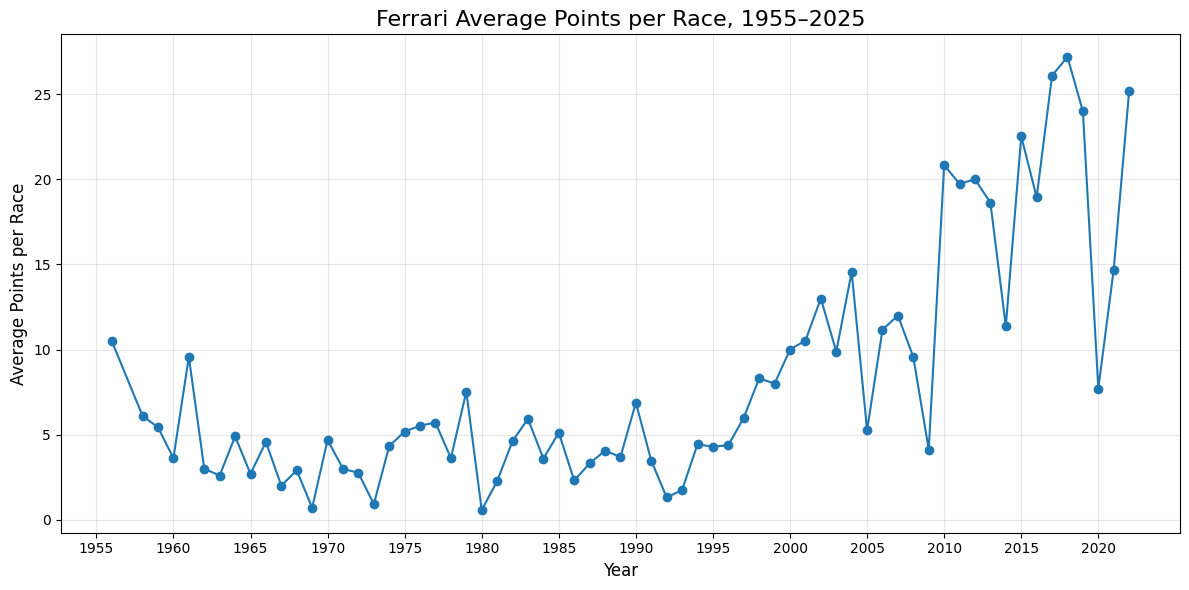

In [ ]:
import pandas as pd

results = pd.read_csv("C:/Users/adamk/OneDrive/Documents/GitHub/datasci530fall2026/Lecture 03/data_raw/constructor_results.csv")
races = pd.read_csv("C:/Users/adamk/OneDrive/Documents/GitHub/datasci530fall2026/Lecture 03/data_raw/races.csv")

# Merge constructor results with race year
ferrari_results = results.merge(
    races[['raceId', 'year']],
    on='raceId',
    how='left'
)

# Keep Ferrari (constructorId = 6) and the requested years
ferrari_results = ferrari_results[
    (ferrari_results['constructorId'] == 6)
]

# Calculate Ferrari's total and average points for each year
ferrari_yearly = (
    ferrari_results
    .groupby('year')
    .agg(
        total_points=('points', 'sum'),
        average_points_per_race=('points', 'mean'),
        races=('raceId', 'count')
    )
    .reset_index()
)

# Round the average for easier interpretation
ferrari_yearly['average_points_per_race'] = (
    ferrari_yearly['average_points_per_race'].round(2)
)

# Display the table
print(ferrari_yearly)

# Create a figure showing Ferrari's average points per race
# over the 1981-2020 period.
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    ferrari_yearly['year'],
    ferrari_yearly['average_points_per_race'],
    marker='o',
    linewidth=1.5
)

plt.title(
    'Ferrari Average Points per Race, 1955–2025',
    fontsize=16
)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Points per Race', fontsize=12)

plt.xticks(
    range(1955, 2025, 5)
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
# Identify the years with the highest and lowest average points per race
best_year = ferrari_yearly.loc[
    ferrari_yearly['average_points_per_race'].idxmax()
]

worst_year = ferrari_yearly.loc[
    ferrari_yearly['average_points_per_race'].idxmin()
]

print(
    f"Highest average: {int(best_year['year'])} "
    f"({best_year['average_points_per_race']:.2f} points per race)"
)

print(
    f"Lowest average: {int(worst_year['year'])} "
    f"({worst_year['average_points_per_race']:.2f} points per race)"
)

Highest average: 2018 (27.19 points per race)
Lowest average: 1980 (0.57 points per race)


The figure shows that Ferrari's average points per race varied considerably since being invented. However, one thing that is clearly apparent is that over time, the average number of points per race increased substantially over time, starting in the 1990's. In the years following the inception of Ferrari, the average number of points usually did not exceed double digits; yet after 2000, the average number of points remained consistently in double digits. This provides additional insight beyond simply counting Ferrari's drivers because it suggests that Ferrari was able to significantly improve their models over time to prioritize speed and power, as indicated by the large increase in average points per race. While there are very noticeable peaks and dips in average points per race from year to year, there is a clear long-term increase in average points per race from Ferrari's inception year to today.